# Data Collection and Preparation - Health Emergencies Preparedness and Response Program (HEPR)

This notebook is a template workflow to collect data and prepare the main data to perform a baseline physical accessibility analysis to health facilities. It uses various tools developed by the World Bank's Geospatial Operations Support Team (GOST).

This notebook focuses on a raster-based implementation of market access, using the motorized Global Friction Surface from the [Malaria Atlas Project](https://malariaatlas.org/project-resources/accessibility-to-healthcare/).
Additionaly, it uses population data from [World Pop](https://hub.worldpop.org/project/categories?id=3) (Unconstrained UN-Adjusted 2020, 1km resolution).

## Data Download Links
- [World Pop Raster](https://data.worldpop.org/GIS/Population/Global_2000_2020_1km/2020/)
- [Friction Surface](https://malariaatlas.org/geoserver/ows?service=CSW&version=2.0.1&request=DirectDownload&ResourceId=Explorer:2020_motorized_travel_time_to_healthcare)

## 0.Setup

Import packages required for the analysis

In [22]:
import sys
from os.path import join, expanduser
import geopandas as gpd
import pandas as pd
from gadm import GADMDownloader
from tqdm import tqdm

In [23]:
# Visualization tools
# import folium as flm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from rasterio.plot import plotting_extent
from rasterio.plot import show
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [24]:
# Raster
import rasterio as rio
import numpy as np
from shapely.geometry import Polygon, box, Point
import skimage.graph as graph

# Graph
import pickle
import networkx as nx
import osmnx as ox

In [25]:
# Climate/Flood

import xarray as xr

In [26]:
# Define your path to the Repositories

sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'gostrocks', 'src'))
sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'GOSTNets_Raster', 'src'))
sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'GOSTnets'))
sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'GOST_Urban', 'src', 'GOST_Urban'))

import GOSTnets as gn
from GOSTnets.load_osm import *
import GOSTRocks.rasterMisc as rMisc
from GOSTRocks.misc import get_utm
import GOSTNetsRaster.market_access as ma
import UrbanRaster as urban

In [27]:
# auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Define below the local folder where you are located

In [28]:
scratch_dir = join(expanduser("~/OneDrive - WBG"), 'Health-Access-Metrics')

## 1. Data Preparation

### Administrative boundaries

In [29]:
country = 'Malawi'
iso = 'MWI'
downloader = GADMDownloader(version="4.0")
adm0 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=0)

<Axes: >

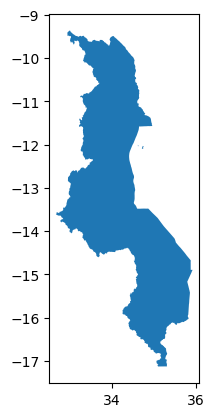

In [30]:
adm0.plot()

### Population (origin)

In [31]:
# wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020/MOSAIC_ppp_prj_2020', f'ppp_prj_2020_{iso}.tif') # Download from link above
wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020', f'ppp_2020_1km_Aggregated.tif') # Download from link above

wp_rio = rio.open(wp_path)
pop_surf = rio.open(wp_path)

### Health Facilities (destinations)

In [32]:
hf_path = join(expanduser("~/OneDrive - WBG"), 'Health-Access-Metrics', 'data', 'MWI', 'HF_Malawi.xlsx')
df_hf = pd.read_excel(hf_path)
df_hf

,Facility Name,Village,GVH,TA,District,Region,Eastings,Northings,Datum,Facility Type,Controlling Agency,Name,Phone,Email,Cluster,Status,Date
0,CHITIPA DH,Mkombanyama,Mkombanyama,Mwawulambya,Chitipa,North,33.265889,-9.701577,WGS 84,Hospital,MoH,Dzinkambani Kambalame,991183141,dzinkambalame@gmail.com,Chitipa DH,Functional,2016-07-01
1,NGOYA,Mphala,Mwakawanga,Mwawulambya,Chitipa,North,33.293329,-9.617792,WGS 84,Health Post,MoH,Martha Mwanza,884254076,NaN,Chitipa DH,Functional,2016-07-01
2,KALIRA,Flyson,Mwanisenga,Mwawulambya,Chitipa,North,33.312223,-9.575143,WGS 84,Outreach,MoH,Jonathan Muyila,991818899,NaN,Chitipa DH,Functional,2016-07-01
3,KALIRA,Flyson,Mwanisenga,Mwawulambya,Chitipa,North,33.312223,-9.575143,WGS 84,Village Clinic,MoH,Jonathan Muyila,991818899,NaN,Chitipa DH,Functional,2016-07-01
4,KALIRA,Flyson,Mwanisenga,Mwawulambya,Chitipa,North,33.312223,-9.575143,WGS 84,Health Post,MoH,Jonathan Muyila,991818899,NaN,Chitipa DH,Functional,2016-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,MLOLO,Chipondeni,Chipondeni,Mlolo,Nsanje,South,35.152560,-16.419711,WGS 84,Health Post,MoH,Charlie Mateyu,881148416,NaN,Mlolo,Functional,2016-09-01
9494,KHANA,Khana,Gatoma,Mlolo,Nsanje,South,35.179200,-16.377098,WGS 84,Outreach,MoH,Caroline Allan,888601487,NaN,Mlolo,Functional,2016-09-01
9495,KHANA,Khana,Gatoma,Mlolo,Nsanje,South,35.179200,-16.377098,WGS 84,Village Clinic,MoH,Caroline Allan,888601487,NaN,Mlolo,Functional,2016-09-01
9496,KANDODO,Gowoke,Gowoke,Mlolo,Nsanje,South,35.159567,-16.405433,WGS 84,Outreach,MoH,Charity Bramu,888595161,NaN,Mlolo,Functional,2016-09-01


In [33]:
hf_type = list(df_hf['Facility Type'].unique())
print(hf_type)

['Hospital', 'Health Post', 'Outreach', 'Village Clinic', 'Health Centre', 'Dispensary']


#### Subset a Health Facility type 

In [34]:
facility = 'Hospital'
df_hf = df_hf.loc[df_hf['Facility Type'] == facility]

Convert the HF from pandas.Dataframe to Geopandas.dataframe

In [35]:
geodf_hf = gpd.GeoDataFrame(
    df_hf, geometry=gpd.points_from_xy(df_hf.Eastings, df_hf.Northings), crs="EPSG:4326"
)

Clean the Geopandas df

In [36]:
geodf_hf = geodf_hf[['Facility Name', 'geometry']]
geodf_hf.loc[:, 'ID'] = df_hf.index
geodf_hf


,Facility Name,geometry,ID
0,CHITIPA DH,POINT (33.26589 -9.70158),0
214,KARONGA DH,POINT (33.91076 -9.95506),214
367,CHILUMBA,POINT (34.25147 -10.43240),367
442,ATUPELE,POINT (33.83755 -9.73631),442
458,KAPORO,POINT (33.87465 -9.76753),458
...,...,...,...
9061,MONTFORT,POINT (34.86908 -16.25632),9061
9229,NGABU,POINT (34.89222 -16.45934),9229
9272,NSANJE DH,POINT (35.25995 -16.91768),9272
9398,KALEMBA,POINT (35.11150 -16.57579),9398


### Flood extent

Here, we import Fathom flood data (.tif) of fluvial floods with different return periods. \
This data represent and mimic the climate impact on infrastructure and the disruption of the accessibility to health facilities.  

In [37]:
# Use rasterio to open the file
# flooded area:      999
# not-flooded area: -9999

fld_path = join(expanduser("R:/"), 'Data', 'GLOBAL','FLOOD_SSBN','v2_2019/malawi', 'fluvial_undefended', 'FU_1in5.tif')
fld_rio = rio.open(fld_path)
fld_rio.read(1)

array([[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       ...,
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],
      dtype=float32)

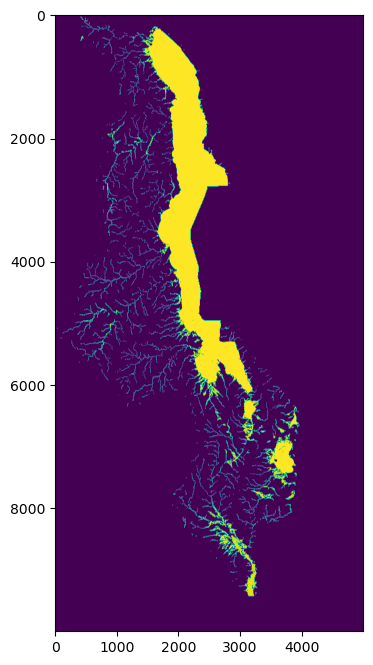

In [38]:
fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(fld_rio.read(1), norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

### Friction Surface

Process the travel cost surface from the Malaria Atlas Project, clip the raster to our region of interest.

In [39]:
# # Only the first time, clip the travel friction surface to the country of interest

# gfs_path = join(expanduser("R:/"), 'Data', 'GLOBAL/INFRA/FRICTION_2020', '2020_motorized_friction_surface.geotiff') # Download from link above
# gfs_rio = rio.open(gfs_path)
# out_travel_surface = join(scratch_dir, 'data', f"travel_surface_motorized_{iso}.tif")
# rMisc.clipRaster(gfs_rio, adm0, out_travel_surface, crop=False)

In [40]:
# Import the clipped friction surface

out_travel_surface = join(scratch_dir, 'data', f"travel_surface_motorized_{iso}.tif")
travel_surf = rio.open(out_travel_surface)
travel_surf

<open DatasetReader name='C:/Users/wb618081/OneDrive - WBG/Health-Access-Metrics/data/travel_surface_motorized_MWI.tif' mode='r'>

In [41]:
print(travel_surf.res)
print(pop_surf.res)

(0.008333333333333333, 0.008333333333333333)
(0.0083333333, 0.0083333333)


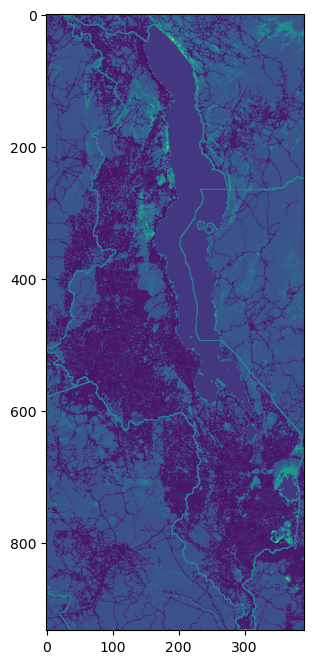

In [42]:
fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(travel_surf.read(1), norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

Align the population raster to the friction surface, ensuring that they have the same extent and resolution.

In [43]:
out_pop_surface_std = join(scratch_dir, 'data', "WP_2020_1km_STD_test.tif")
rMisc.standardizeInputRasters(pop_surf, travel_surf, out_pop_surface_std, resampling_type="nearest")

[array([[[67.61455  , 70.83097  , 96.48191  , ...,  4.846376 ,
           7.727382 ,  7.5541716],
         [61.91576  , 62.618916 , 77.278244 , ...,  2.8063774,
           6.704942 ,  7.74414  ],
         [53.38135  , 55.781017 , 64.322914 , ...,  1.6051795,
           4.2656183,  4.0875587],
         ...,
         [32.477394 , 28.508108 , 25.174734 , ..., 15.47292  ,
          14.119669 , 12.792173 ],
         [30.201307 , 31.671202 , 31.06995  , ..., 16.121716 ,
          14.633034 , 13.378336 ],
         [33.76848  , 32.88883  , 32.243195 , ..., 14.960836 ,
          14.153514 , 13.6319685]]], dtype=float32),
 {'driver': 'GTiff',
  'dtype': 'float32',
  'nodata': -3.4028234663852886e+38,
  'width': 390,
  'height': 933,
  'count': 1,
  'crs': CRS.from_epsg(4326),
  'transform': Affine(0.008333333333333333, 0.0, 32.66666666666666,
         0.0, -0.008333333333333333, -9.358333333333334)}]

### Origins

We prepare a standard grid using each cell from the 1km World Pop raster.

In [45]:
pop_surf = rio.open(out_pop_surface_std)
pop = pop_surf.read(1, masked=False)
pop_surf.read_crs()

CRS.from_epsg(4326)

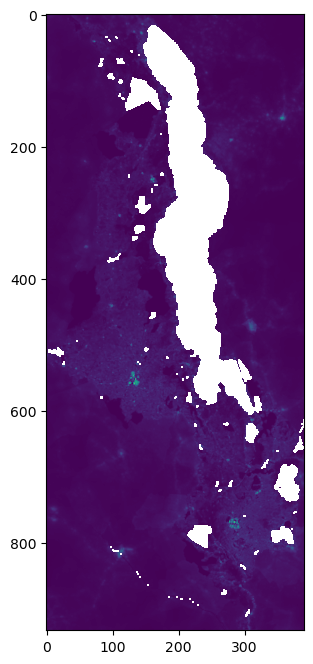

In [46]:
pop_copy = pop.copy()
pop_copy[pop_copy==0] = np.nan

fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(pop_copy, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

In [81]:
pop_surf.xy(0,0)

(32.67083333333333, -9.3625)

In [82]:
indices = list(np.ndindex(pop.shape))
xys = [Point(pop_surf.xy(ind[0], ind[1])) for ind in indices]
res_df = pd.DataFrame({
    'spatial_index': indices, 
    'xy': xys, 
    'pop': pop.flatten()
})
res_df['pointid'] = res_df.index
res_df

,spatial_index,xy,pop,pointid
0,"(0, 0)",POINT (32.67083333333333 -9.3625),67.614548,0
1,"(0, 1)",POINT (32.67916666666666 -9.3625),70.830971,1
2,"(0, 2)",POINT (32.68749999999999 -9.3625),96.481911,2
3,"(0, 3)",POINT (32.695833333333326 -9.3625),111.579651,3
4,"(0, 4)",POINT (32.70416666666666 -9.3625),161.928329,4
...,...,...,...,...
363865,"(932, 385)",POINT (35.879166666666656 -17.129166666666666),32.535667,363865
363866,"(932, 386)",POINT (35.88749999999999 -17.129166666666666),24.958359,363866
363867,"(932, 387)",POINT (35.89583333333332 -17.129166666666666),14.960836,363867
363868,"(932, 388)",POINT (35.904166666666654 -17.129166666666666),14.153514,363868


Create an MCP graph object from the friction surface.

In [83]:
# convert friction surface to traversal time (lazily). Original data are minutes to travel 1 m:
# We convert it to minutes to cross the cell (1000m). This could be revised

inG_data = travel_surf.read(1) * 1000

# Correct no data values. Not needed but good to check
# inG_data[inG_data < 0] = 99999999
# inG_data[inG_data < 0] = np.nan
mcp = graph.MCP_Geometric(inG_data)

In [84]:
print(f"Mean: {np.mean(inG_data)}")
print(f"Max: {np.max(inG_data)}")
print(f"Min: {np.min(inG_data)}")
print(f"Std: {np.std(inG_data)}")

Mean: 10.535689353942871
Max: 205.40260314941406
Min: 0.5
Std: 10.9324312210083


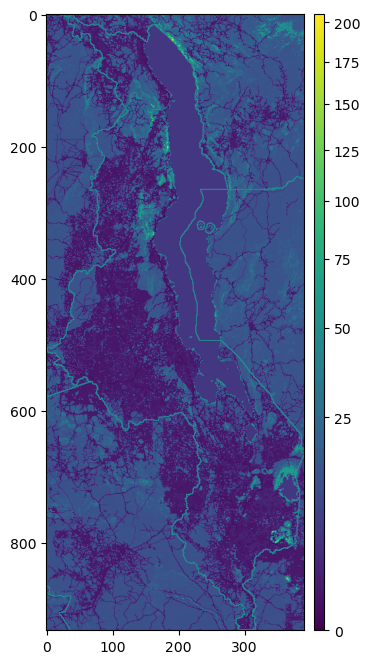

In [85]:
# Plot the Travel Time surface

copy = inG_data.copy()
copy[copy<0] = np.nan

fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(copy, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')
divider = make_axes_locatable(ax)

cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')

## 2. Data analysis

In [86]:
len(res_df), len(geodf_hf)

(363870, 85)

Calculate the travel time from each grid-cell to the nearest destination

In [87]:
res = ma.calculate_travel_time(travel_surf, mcp, geodf_hf)[0]
res

array([[ 205.36438346,  203.86438346,  195.77445864, ..., 1158.11912476,
        1171.1072167 , 1184.19670569],
       [ 205.9857038 ,  212.85261988,  199.65060865, ..., 1155.1124393 ,
        1168.28872743, 1181.69441333],
       [ 215.46197066,  214.43606638,  197.0513637 , ..., 1150.01513963,
        1163.47204118, 1177.16571383],
       ...,
       [ 467.89505936,  454.28047635,  445.75496626, ...,  293.54816257,
         295.37215549,  306.70857608],
       [ 462.50430844,  448.86050627,  434.97523377, ...,  308.08119975,
         308.50703651,  313.9869167 ],
       [ 458.83065196,  444.94388934,  431.32569953, ...,  321.60480557,
         321.84875471,  327.21095888]])

In [88]:
len(res.flatten()), len(res_df)

(363870, 363870)

In [89]:
res_df.loc[:, 'tt_hf_min'] = res.flatten()
res_df

,spatial_index,xy,pop,pointid,tt_hf_min
0,"(0, 0)",POINT (32.67083333333333 -9.3625),67.614548,0,205.364383
1,"(0, 1)",POINT (32.67916666666666 -9.3625),70.830971,1,203.864383
2,"(0, 2)",POINT (32.68749999999999 -9.3625),96.481911,2,195.774459
3,"(0, 3)",POINT (32.695833333333326 -9.3625),111.579651,3,187.684534
4,"(0, 4)",POINT (32.70416666666666 -9.3625),161.928329,4,186.184534
...,...,...,...,...,...
363865,"(932, 385)",POINT (35.879166666666656 -17.129166666666666),32.535667,363865,323.800888
363866,"(932, 386)",POINT (35.88749999999999 -17.129166666666666),24.958359,363866,322.925962
363867,"(932, 387)",POINT (35.89583333333332 -17.129166666666666),14.960836,363867,321.604806
363868,"(932, 388)",POINT (35.904166666666654 -17.129166666666666),14.153514,363868,321.848755


In [90]:
# remove values where pop is 0 or nan
res_df = res_df.loc[res_df['pop']!=0].copy()
res_df = res_df.loc[~(res_df['pop'].isna())].copy()

In [91]:
res_df.loc[:,'xy'] = res_df.loc[:,'xy'].apply(lambda x: Point(x))

Create Geodataframe for the population grid

In [92]:
origins = gpd.GeoDataFrame(res_df, geometry='xy', crs='EPSG:4326')
origins

,spatial_index,xy,pop,pointid,tt_hf_min
0,"(0, 0)",POINT (32.67083 -9.36250),67.614548,0,205.364383
1,"(0, 1)",POINT (32.67917 -9.36250),70.830971,1,203.864383
2,"(0, 2)",POINT (32.68750 -9.36250),96.481911,2,195.774459
3,"(0, 3)",POINT (32.69583 -9.36250),111.579651,3,187.684534
4,"(0, 4)",POINT (32.70417 -9.36250),161.928329,4,186.184534
...,...,...,...,...,...
363865,"(932, 385)",POINT (35.87917 -17.12917),32.535667,363865,323.800888
363866,"(932, 386)",POINT (35.88750 -17.12917),24.958359,363866,322.925962
363867,"(932, 387)",POINT (35.89583 -17.12917),14.960836,363867,321.604806
363868,"(932, 388)",POINT (35.90417 -17.12917),14.153514,363868,321.848755


In [93]:
origins.rename(columns={'xy':'geometry'}, inplace=True)
origins.set_geometry('geometry', inplace=True)

In [94]:
# convert travel time to hours
origins.loc[:, "tt_hf_min_hrs"] = origins.loc[:, "tt_hf_min"] / 60

In [95]:
origins.head(2)

,spatial_index,geometry,pop,pointid,tt_hf_min,tt_hf_min_hrs
0,"(0, 0)",POINT (32.67083 -9.36250),67.614548,0,205.364383,3.42274
1,"(0, 1)",POINT (32.67917 -9.36250),70.830971,1,203.864383,3.39774


In [96]:
origins.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Save results as raster

In [100]:
# tt_raster = join(scratch_dir, f"tt_hf_min_motorized_friction_{facility}.tif")
tt_raster = join(scratch_dir, f"tt_hf_min_motorized_friction_test.tif")

In [101]:
rMisc.rasterizeDataFrame(
    inD = origins,
    outFile = tt_raster,
    idField = 'tt_hf_min_hrs',
    templateRaster = out_travel_surface
)

## Map Results

In [102]:
tt_rio = rio.open(tt_raster)
tt_rio

<open DatasetReader name='C:/Users/wb618081/OneDrive - WBG/Health-Access-Metrics/tt_hf_min_motorized_friction_test.tif' mode='r'>

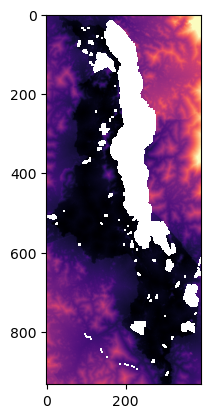

In [103]:
plt.imshow(tt_rio.read(1), vmin=0, vmax=16, cmap='magma')

Text(0.85, 0.76, 'Travel Time (hrs.)')

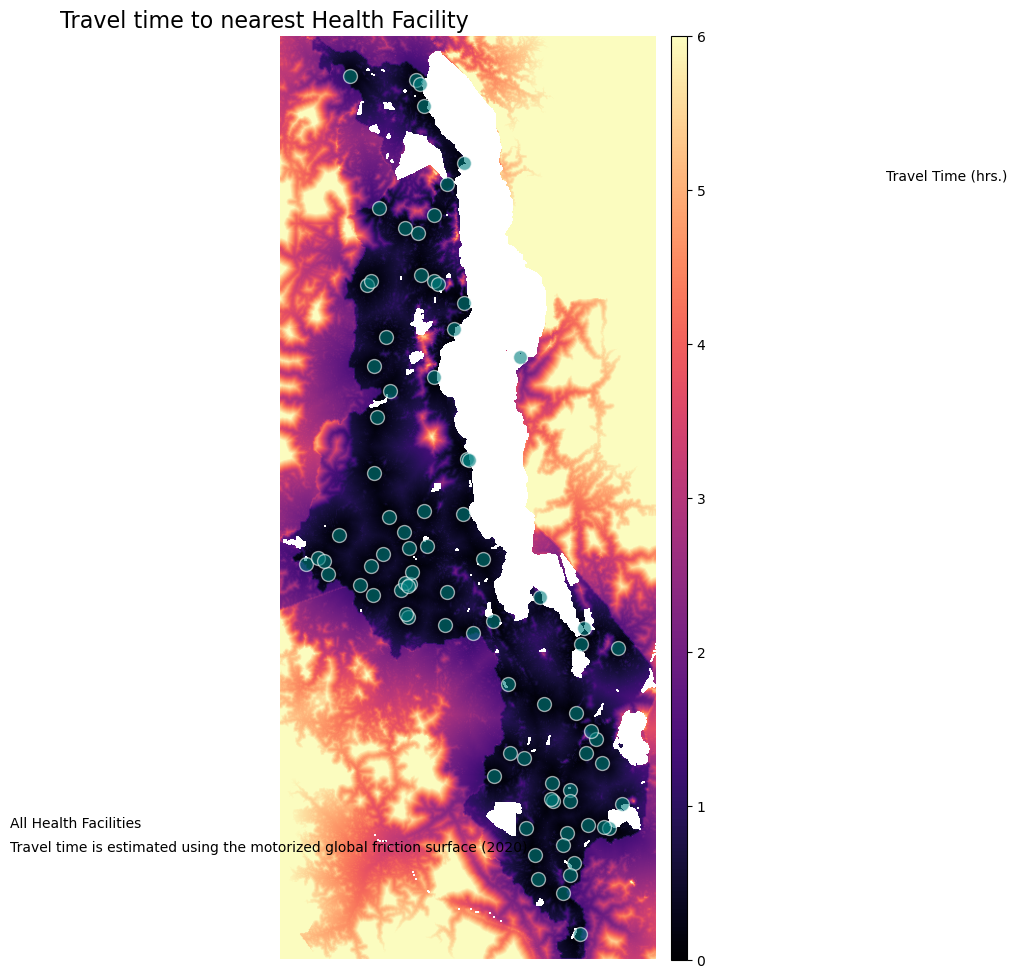

In [106]:
# Plot

figsize = (12, 12)
fig, ax = plt.subplots(1, 1,  figsize = figsize)
ax.set_title("Travel time to nearest Health Facility", fontsize=16, horizontalalignment='right')
plt.axis('off')
ext = plotting_extent(tt_rio)
im = ax.imshow(tt_rio.read(1), vmin=0, vmax=6, cmap='magma', extent=ext)
geodf_hf.plot(ax=ax, facecolor='teal', edgecolor='white', markersize=100, alpha=0.6)
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs='EPSG:4326', zorder=-1)
txt="All Health Facilities"
txt2 = "Travel time is estimated using the motorized global friction surface (2020)"
plt.figtext(0.12, 0.22, txt, wrap=True, horizontalalignment='left', fontsize=10)
plt.figtext(0.12, 0.2, txt2, wrap=True, horizontalalignment='left', fontsize=10)
plt.figtext(0.85, 0.76, "Travel Time (hrs.)", wrap=False, fontsize=10)
# plt.savefig("travel-time-friction.png", dpi=300, bbox_inches='tight', facecolor='white')